# Create a mock makemore code that can generate new strings for the simulation

## current knowledge of makemore includes developing embedded vectors and large matrices that can use either manual or built in pytorch back propogation

### dataset can be interchanged

In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import random

torch.set_num_threads(1)
torch.set_num_interop_threads(1)

In [ ]:
# read command strings

commands = []
scores = []

with open('sequences_5000.txt','r') as t:
    for line in t:
        line = line.strip()
        if line:
            seq, score_str = line.rsplit(' ',1)
            commands.append(seq)
            scores.append(int(score_str))

# turn vocab into integers
actions = sorted(list(set(''.join(commands))))
stoi = {s:i+1 for i,s in enumerate(actions)}
stoi[','] = 0 # signify when task is complete
itos = {i:s for s,i in stoi.items()}
command_size = len(itos)
print(itos)
print(command_size)

{1: '.', 2: 'a', 3: 'd', 4: 'e', 5: 's', 6: 'w', 0: ','}
7
[4940, 2252, 8701, 2130, 2718, 2812, 2902, 4419, 7625, 6498, 4379, 2013, 8904, 9015, 1393, 1024, 8177, 2196, 7861, 6896, 2726, 6992, 2251, 3572, 2358, 4104, 7746, 3982, 9546, 4206, 9628, 6982, 7757, 8393, 1862, 9727, 1311, 9831, 7887, 4347, 4254, 6564, 6035, 1896, 6782, 2068, 8065, 4566, 6866, 8242, 1104, 3491, 1814, 4108, 5963, 9626, 1297, 1516, 9043, 2172, 2177, 5330, 3998, 9452, 9664, 3649, 9979, 9019, 7731, 1634, 9715, 4670, 1726, 9722, 8802, 3692, 8003, 4109, 8053, 7913, 9208, 7498, 1751, 7537, 3340, 9389, 4947, 5881, 6815, 2414, 8385, 4325, 6805, 2236, 7512, 2022, 8626, 2121, 4594, 1623, 4395, 4232, 1729, 8215, 6098, 7725, 6633, 2730, 2617, 4163, 4746, 7752, 3077, 8473, 7894, 7429, 7474, 5160, 7064, 2281, 6100, 3637, 6190, 2377, 6427, 6195, 6730, 7603, 8503, 8067, 2440, 8787, 6586, 3106, 6588, 6079, 8078, 4037, 8527, 9735, 7523, 1521, 2189, 9790, 6916, 8365, 6180, 3803, 3168, 5244, 2757, 5070, 6259, 4142, 8426, 1207, 6213

In [ ]:
# build database

block_size = 5 # context length: how many commands do we look ahead to

def build_dataset(commands):  
  X, Y = [], []
  
  for a in commands:
    context = [0] * block_size
    for ch in a + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

# create training/developer/testing data
import random
random.seed(42)
random.shuffle(commands)

n1 = int(0.8*len(commands))
n2 = int(0.9*len(commands))

Xtr, Ytr = build_dataset(commands[:n1])       # 80%
Xdev, Ydev = build_dataset(commands[n1:n2])   # 10%
Xte, Yte = build_dataset(commands[n2:])       # 10%


torch.Size([111318, 5]) torch.Size([111318])
torch.Size([14424, 5]) torch.Size([14424])
torch.Size([13956, 5]) torch.Size([13956])


In [29]:
# Initialize MLP

n_embd = 2 # dimensionality of the action embedding vector
n_hidden = 64 # number of neuronsi n hidden layer of the MLP

g = torch.Generator().manual_seed(1)
C = torch.randn((command_size,n_embd),generator=g)
# layer 1
W1 = torch.randn((n_embd*block_size,n_hidden),generator = g)
W1 *= (5/3)/((n_embd * block_size)**0.5) # add gain
# skip b1
# layer 2
W2 = torch.randn((n_hidden,command_size),generator=g) * 0.1
b2 = torch.randn(command_size, generator=g) * 0.1
# Batchnorm parameters
bngain = torch.randn((1,n_hidden)) * 0.1 + 1.0
bnbias = torch.randn((1,n_hidden)) * 0.1
bnmean_running = torch.zeros((1,n_hidden))
bnstd_running = torch.ones((1,n_hidden))


# initialize gradient
parameters = [C,W1,W2,b2,bngain,bnbias]
print(sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad = True

1237


In [30]:
# optimization 

max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
    # Mini batch development
    ix = torch.randint(0, Xtr.shape[0],(batch_size,),generator = g)
    Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y

    # forward pass
    emb = C[Xb]
    embcat = emb.view(emb.shape[0],-1)
    hpreact = embcat @ W1
    bnmeani = hpreact.mean(0,keepdim = True)
    bnstdi = hpreact.std(0,keepdim = True)
    hpreact = bngain * (hpreact - bnmeani) / bnstdi + bnbias # batch normalization/ unit gaussian the layer 

    # like gradient descending but horribly simplified
    with torch.no_grad():
        bnmean_running = 0.999 * bnmean_running + 0.001 * bnmeani
        bnstd_running = 0.999 * bnstd_running + 0.001 * bnstdi 

    h = torch.tanh(hpreact) # hidden layer
    logits = h @ W2 + b2 # output layer
    loss = F.cross_entropy(logits, Yb) # loss function

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.1 if i < 10000 else 0.01 # learning rate decay
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps:7d} : {loss.item():.4f}')
    lossi.append(loss.log10().item())
    # break    

      0/ 200000 : 2.0697
  10000/ 200000 : 0.6769
  20000/ 200000 : 0.3580
  30000/ 200000 : 0.2629
  40000/ 200000 : 0.3468
  50000/ 200000 : 0.5893
  60000/ 200000 : 0.5531
  70000/ 200000 : 0.5337
  80000/ 200000 : 0.4085
  90000/ 200000 : 0.3785
 100000/ 200000 : 0.4622
 110000/ 200000 : 0.5592
 120000/ 200000 : 0.3182
 130000/ 200000 : 0.5185
 140000/ 200000 : 0.4737
 150000/ 200000 : 0.3781
 160000/ 200000 : 0.2658
 170000/ 200000 : 0.4697
 180000/ 200000 : 0.7059
 190000/ 200000 : 0.3916


In [31]:
torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
    x,y = {
        'train': (Xtr, Ytr),
        'val': (Xdev,Ydev),
        'test': (Xte,Yte),
    }[split]
    emb = C[x] # (N,block_size,n_embd)
    embcat = emb.view(emb.shape[0],-1) # concat into (N,block_size * n_embd)
    hpreact = embcat @ W1
    hpreact = bngain * (hpreact - bnmean_running) / bnstd_running + bnbias
    h = torch.tanh(hpreact) # (N, n_hidden)
    logits = h @ W2 + b2 # (N, vocab_size)
    loss = F.cross_entropy(logits,y)
    print(split,loss.item())

split_loss('train')
split_loss('val')


train 0.4073386490345001
val 0.3981640636920929


In [10]:
# sample from the model
g = torch.Generator().manual_seed(-123)

for _ in range(25):

    out = []
    context = [0] * block_size # initialize with all ... 
    while True:
        emb = C[torch.tensor([context])] # (1,block_size,n_embd)
        h = torch.tanh(emb.view(1,-1) @ W1)
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs,num_samples=1,generator=g).item()
        # shift the context window and track the sample
        context = context[1:] + [ix]
        out.append(ix) 
        # if we sample the special '.' token, break
        if ix == 0:
            break

    print(''.join(itos[i] for i in out)) # decode and print the generated word

dwewwasesssseaassdsewwdddssseddwwwwdssswdd,
wwwessases.....aadsssseaaas.........wwwwsssseddwwwedessas.aessssddwwwesasss.ww...eeadsseeaasssee.......aasssssaaas.....aaasssse.......aassaa,
ddwwe.ssseda......dwwwddssses...........aasssseaaa,
dwweewwesessswasesee........daaasesseaea.s......asssseaad.....asssseas......assssed.wwddsss.aeasessssse.aaaadsssseasseas.....aeasawwe..ss.ssasss.a,
wwweeassesss.........sssseasw......dsssas...aassssseweaasssee..................aaseaaaee.....sssseaasssseeasss.........as.....dasss.....ssssedwwwwwe.sssee.....ddwwwdsssse.wwweaass.eeeassssssewww.........ssseeaaaa.....aaassawwaaddaaasssseww,
dawws.e.s.ssass......,
wed,
dssseadaaaaassss..........,
ddwweedesseaaaw...sedwwwwweesssaad........s.sss.a...aassss......assssssswws.weawds...........ssseaaweasssse.a.....sssssdddseesssseewewwwsssss.........assssea..............wwwwwwe..as.....sssseassswweeeasee.....asass.....aadssseaasssss.......,
dwewesssee.......wwasssaas..e........aassss......aaasssseaassssss.....asda

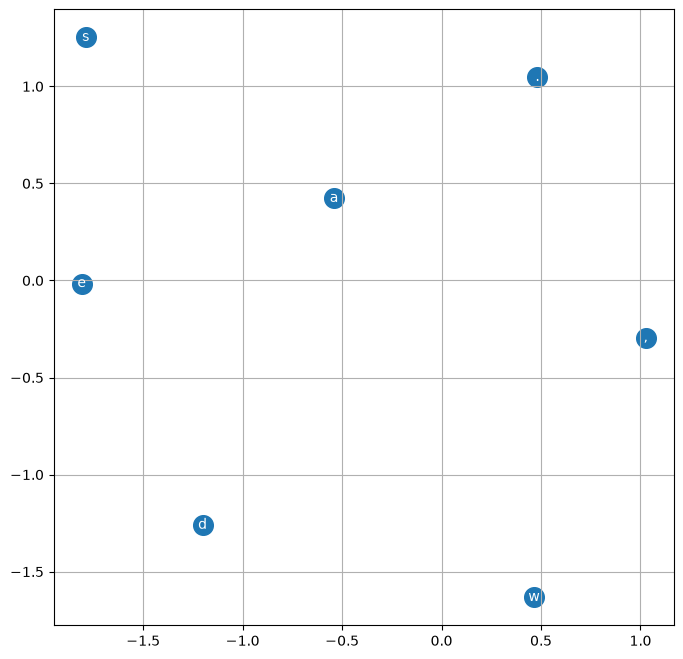

In [32]:
# visualize the commands with embedding coordinates (as there are only 2), (x coords is 0, y coords is 1)

plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data,C[:,1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(),C[i,1].item(),itos[i],ha="center",va="center",color="white")
plt.grid('minor')